<a href="https://colab.research.google.com/github/SaiSiri05/MachineLearning_Labs/blob/main/Implementing_KNN_from_scratch_and_visualize_Algorithm_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# =========================================================
# IMPORT REQUIRED LIBRARIES
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import distance, Voronoi, voronoi_plot_2d

from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

import pandas as pd

In [27]:
def minkowski_distance(x1, x2, p):
    """
    Calculate Minkowski distance between two points.
    """
    return np.sum(np.abs(x1 - x2) ** p) ** (1 / p)


# Test your implementation
x_1 = np.array([1, 2, 3])
x_2 = np.array([4, 6, 8])

# Test with p=1 (Manhattan)
print("Minkowski distance (p=1):", minkowski_distance(x_1, x_2, 1))
print("Manhattan distance:", distance.cityblock(x_1, x_2))
print()

# Test with p=2 (Euclidean)
print("Minkowski distance (p=2):", minkowski_distance(x_1, x_2, 2))
print("Euclidean distance:", distance.euclidean(x_1, x_2))

Minkowski distance (p=1): 12.0
Manhattan distance: 12

Minkowski distance (p=2): 7.0710678118654755
Euclidean distance: 7.0710678118654755


In [28]:
# Generate synthetic dataset
def generate_synth_data(n):
    X, y = make_classification(
        n_samples=n,
        n_features=2,
        n_redundant=0,
        n_informative=2,
        n_clusters_per_class=1,
        random_state=42
    )
    return X, y

In [29]:
def plot_decision_boundary(X, y, k_value, metric='euclidean'):
    """
    Plot the decision boundary for KNN classifier.
    """

    # Create mesh grid
    h = 0.02

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Train KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k_value, metric=metric)
    knn.fit(X, y)

    # Predict each point in mesh
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(10, 6))

    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolor='k',
        cmap=plt.cm.coolwarm
    )

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'KNN Decision Boundary (k={k_value}, metric={metric})')

    plt.show()

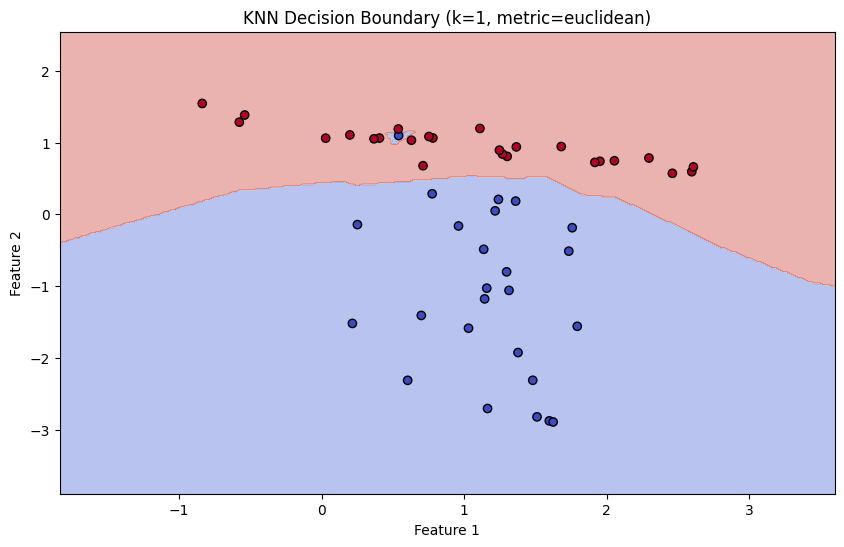

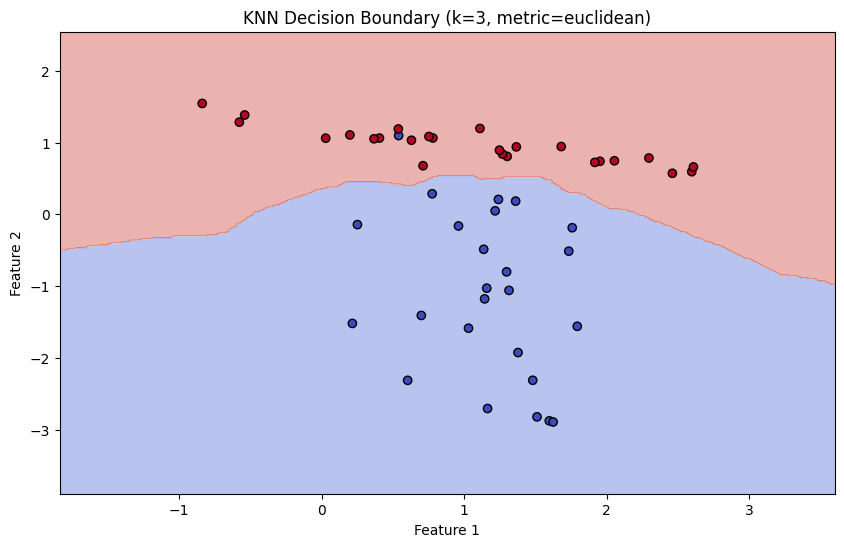

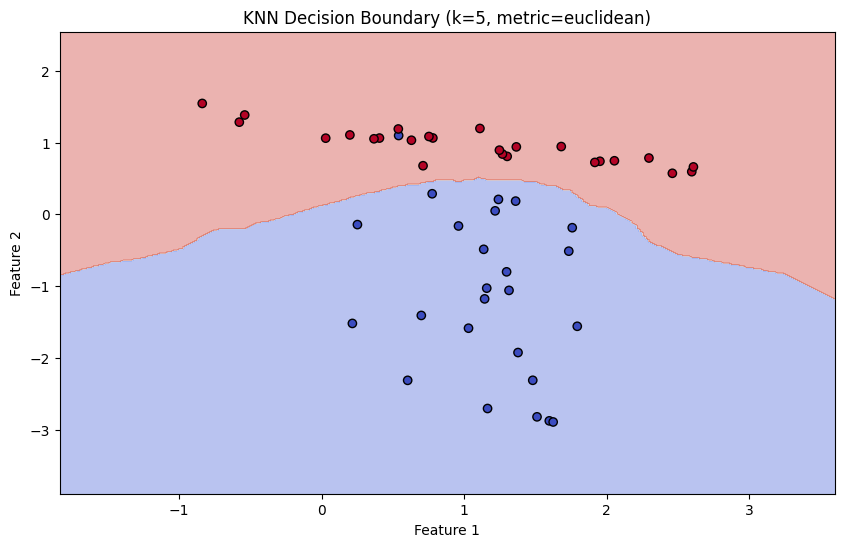

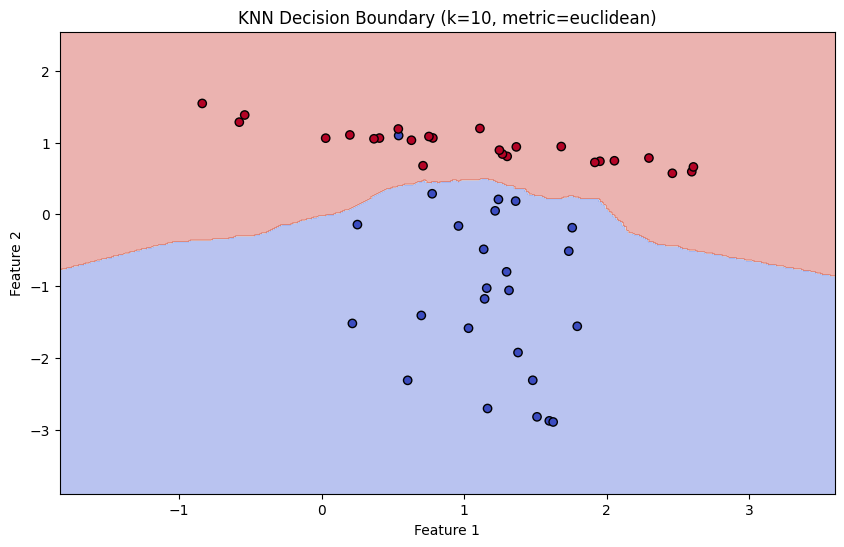

In [30]:
# Generate synthetic data
n = 50
pts, tgts = generate_synth_data(n)

# Test different k values
for k in [1, 3, 5, 10]:
    plot_decision_boundary(pts, tgts, k)

In [31]:
def compare_distance_metrics():

    dimensions = [2, 5, 10, 20, 50, 100, 200]

    euclidean_ratios = []
    manhattan_ratios = []
    cosine_ratios = []

    n_points = 100

    for dim in dimensions:

        # Generate random high-dimensional data
        data = np.random.rand(n_points, dim)

        # Euclidean distances
        euc_dist = distance.pdist(data, metric='euclidean')

        # Manhattan distances
        man_dist = distance.pdist(data, metric='cityblock')

        # Cosine distances
        cos_dist = distance.pdist(data, metric='cosine')

        # Ratio max/min
        euclidean_ratios.append(np.max(euc_dist) / np.min(euc_dist))
        manhattan_ratios.append(np.max(man_dist) / np.min(man_dist))
        cosine_ratios.append(np.max(cos_dist) / np.min(cos_dist))

    # Plot results
    plt.figure(figsize=(10, 6))

    plt.plot(dimensions, euclidean_ratios, marker='o', label='Euclidean')
    plt.plot(dimensions, manhattan_ratios, marker='s', label='Manhattan')
    plt.plot(dimensions, cosine_ratios, marker='^', label='Cosine')

    plt.xlabel("Dimensions")
    plt.ylabel("Max Distance / Min Distance")
    plt.title("Impact of Dimensionality on Distance Metrics")

    plt.legend()
    plt.grid(True)

    plt.show()

In [32]:
# Load dataset
df = pd.read_csv("car_evaluation.csv")

print(df.head())

   vhigh vhigh.1  2 2.1  small   low  unacc
0  vhigh   vhigh  2   2  small   med  unacc
1  vhigh   vhigh  2   2  small  high  unacc
2  vhigh   vhigh  2   2    med   low  unacc
3  vhigh   vhigh  2   2    med   med  unacc
4  vhigh   vhigh  2   2    med  high  unacc


In [33]:
# Encode all categorical columns
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

print(df.head())

   vhigh  vhigh.1  2  2.1  small  low  unacc
0      3        3  0    0      2    2      2
1      3        3  0    0      2    0      2
2      3        3  0    0      1    1      2
3      3        3  0    0      1    2      2
4      3        3  0    0      1    0      2


In [34]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

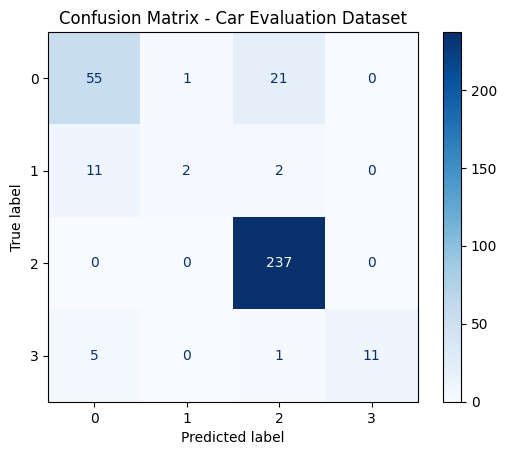

In [36]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Car Evaluation Dataset")

plt.show()

In [37]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.71      0.74        77
           1       0.67      0.13      0.22        15
           2       0.91      1.00      0.95       237
           3       1.00      0.65      0.79        17

    accuracy                           0.88       346
   macro avg       0.84      0.62      0.68       346
weighted avg       0.87      0.88      0.87       346



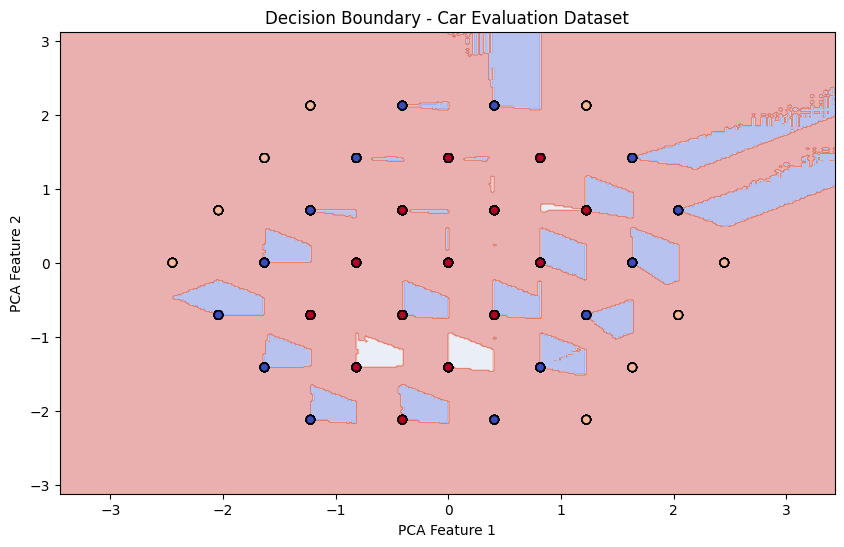

In [38]:
# Reduce dimensions to 2D using PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Train-test split
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

# Train KNN
knn_pca = KNeighborsClassifier(n_neighbors=5)

knn_pca.fit(X_train_pca, y_train_pca)

# Mesh grid
h = 0.02

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)


Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    edgecolor='k',
    cmap=plt.cm.coolwarm
)

plt.title("Decision Boundary - Car Evaluation Dataset")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")

plt.show()

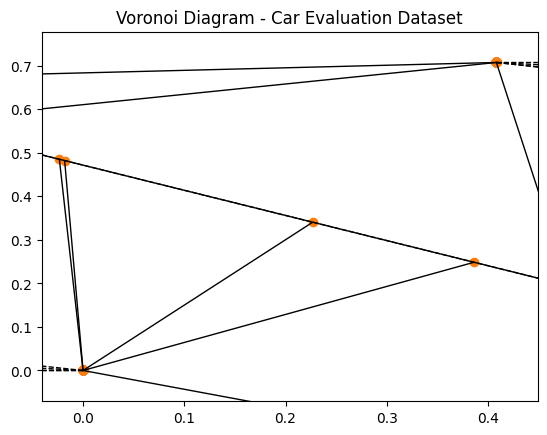

In [40]:
# Use only first 2 PCA features
points = X_pca[:50]

# Create Voronoi diagram
# Added qhull_options='QJ' to handle precision errors due to flat simplex
vor = Voronoi(points, qhull_options='QJ')

# Plot
fig = voronoi_plot_2d(vor)

plt.scatter(points[:, 0], points[:, 1], c='red')

plt.title("Voronoi Diagram - Car Evaluation Dataset")

plt.show()